# Deep Learning for Computer Vision:  HW 4

## Computer Science: COMS W 4995 006

### Due: November 9, 2021

### Problem

In this notebook we provide three networks for classifying handwritten digits from the MNIST dataset. The networks are implemented and tested using the Tensorflow framework. The third and final network is a convolutional neural network (CNN aka ConvNet) which achieves 99.18% accuracy on this dataset. 

Your task is to re-implement all three networks using Pytorch. You will likely find several Pytorch implementations on the internet. It is ok to study these. However, you must not cut and paste this code into your assignment--you must write this yourself. Furthermore, you need to comment every line of code and succintly explain what it is doing! 

Here is what is required:

a) A FULLY commented re-implementation of the networks below using Pytorch.

b) your network trained on the same MNIST data as used here.

c) an evaluation of the accuracy on the MNIST test set.

d) plots of 10 randomly selected digits from the test set along with the correct label and the assigned label.

e) have your training record a log of the validation loss and validation accuracy. 

f) have your training continually save the best model so far (as determined by the validation loss).

g) after training, load the saved weights using the best model so far. re-run you accuracy evaluation using these saved weights.

Below we include the Tensorflow examples shown in class.

### A Simple Convolutional Neural Network in Tensorflow

This notebook covers a python and tensorflow-based solution to the handwritten digits recognition problem. It is based on tensorflow tutorials and Yann LeCun's early work on CNN's. This toturial compares a simple softmax regressor, a multi-layer perceptron (MLP), and a simple convolutional neural network (CNN).

Load in the MNIST digit dataset directly from tensorflow examples.

In [1]:
from tensorflow.examples.tutorials.mnist import input_data
mnist = input_data.read_data_sets('MNIST_data', one_hot=True)

Extracting MNIST_data/train-images-idx3-ubyte.gz
Extracting MNIST_data/train-labels-idx1-ubyte.gz
Extracting MNIST_data/t10k-images-idx3-ubyte.gz
Extracting MNIST_data/t10k-labels-idx1-ubyte.gz


The MNIST data is split into three parts: 55,000 data points of training data (mnist.train), 10,000 points of test data (mnist.test), and 5,000 points of validation data (mnist.validation). 

Let's import tensorflow and begin an interactive session.

In [2]:
import tensorflow as tf
sess = tf.InteractiveSession()

## Softmax Regression Model on the MNIST Digits Data

We need to create placeholders for the data. Data will be dumped here when it is batched from the MNIST dataset.

In [3]:
x = tf.placeholder(tf.float32, shape=[None, 784])
y_ = tf.placeholder(tf.float32, shape=[None, 10])

Now let's see what this data looks like.

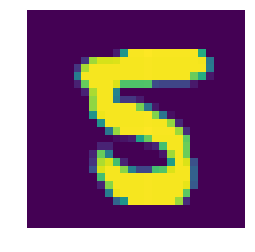

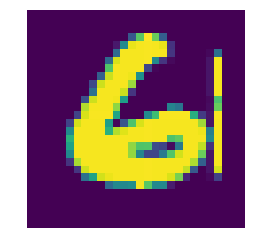

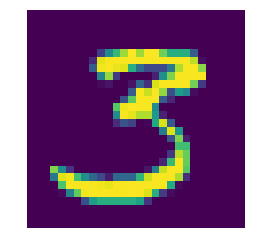

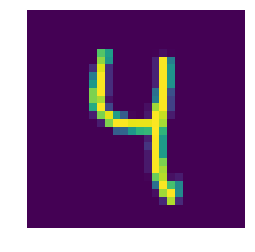

In [4]:
import matplotlib.pyplot as plt
import numpy as np

for i in range(4):
    batch = mnist.test.next_batch(1)
    image = np.asarray(batch[0]).reshape((28, 28))
    label = batch[1]
    
    plt.imshow(image)
    plt.axis("off")
    plt.show()

We are first going to do softmax logistic regression. This is a linear layer followed by softmax. Note there are NO hidden layers here. Also note that the digit images (28x28 grayscale images) are reshaped into a 784 element vector. 

Below we create the parameters (weights) for our linear layer.

In [5]:
W = tf.Variable(tf.zeros([784,10]))
b = tf.Variable(tf.zeros([10]))

We then use tensorflows initializer to initialize these weights.

In [6]:
sess.run(tf.global_variables_initializer())

We create our linear layer as a function of the input and the weights.

In [7]:
y_regressor = tf.matmul(x,W) + b

Below we create our loss function. Note that the cross entropy is $ H_{\hat{y}}(y) = -\sum_i \hat{y}_{i} \, \log(y_{i})$ where $\hat{y}$ is the true probability distribution and is expressed as a one-hot vector, $y$ is the estimated probability distribution, and $i$ indexes elements of these two vectors. Also note that this reduces to $ H_{\hat{y}}(y) = -\, \log(y_{i^*})$ where $i^*$ is the correct label. And if we sum this over all of our samples indexed by $j$, then $H_{\hat{y}}(y) = -\sum_j  \log(y^{(j)}_{i^*})$. This is precisely the same loss function as we used before, but we called the MLE loss. They are one and the same.

In [8]:
cross_entropy = tf.reduce_mean(
    tf.nn.softmax_cross_entropy_with_logits(labels=y_, logits=y_regressor))

Now we tell tf to use gradient descent with a step size of 0.5 and to minimize the cross entropy.

In [9]:
train_step = tf.train.GradientDescentOptimizer(0.5).minimize(cross_entropy)

We train by grabbing mini-batches with 100 samples each and pushing these through the network to update our weights (W and b).

In [10]:
for _ in range(1000):
  batch = mnist.train.next_batch(100)
  train_step.run(feed_dict={x: batch[0], y_: batch[1]})

We define how to compute correct predicitions.

In [11]:
correct_prediction = tf.equal(tf.argmax(y_regressor,1), tf.argmax(y_,1))

And from these correct predictions how to compute the accuracy.

In [12]:
accuracy = tf.reduce_mean(tf.cast(correct_prediction, tf.float32))

In [13]:
print(accuracy.eval(feed_dict={x: mnist.test.images, y_: mnist.test.labels}))

0.919


Let's print out some test images and the corresponsing predictions made by the network. But first, let's add an output to the computation graph that computes the softmax probabilities.

In [14]:
y_probs_regressor = tf.nn.softmax(logits=y_regressor, name=None)

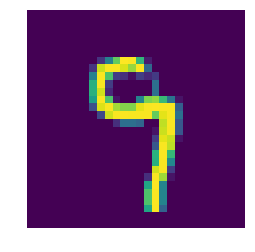

Label =  [[ 0.  0.  0.  0.  0.  0.  0.  0.  0.  1.]]
Class probabilities =  [[  9.29443468e-06   7.47387749e-05   1.38089963e-05   1.14219487e-01
    3.84134240e-02   6.48420528e-02   1.38886957e-04   1.47537813e-02
    1.18470658e-02   7.55687416e-01]]


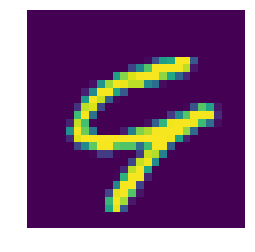

Label =  [[ 0.  0.  0.  0.  0.  0.  0.  0.  0.  1.]]
Class probabilities =  [[  8.50503985e-03   4.94107439e-07   4.09405155e-04   6.29698661e-06
    7.67807290e-02   2.39031506e-04   2.94614192e-02   1.68453693e-01
    8.35071690e-03   7.07793236e-01]]


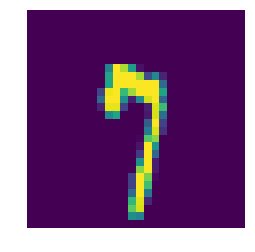

Label =  [[ 0.  0.  0.  0.  0.  0.  0.  1.  0.  0.]]
Class probabilities =  [[  1.15769981e-05   2.45307339e-04   1.97686313e-05   6.34711876e-04
    5.48726879e-04   2.86388420e-03   1.54315749e-05   9.59967077e-01
    4.33111069e-04   3.52605022e-02]]


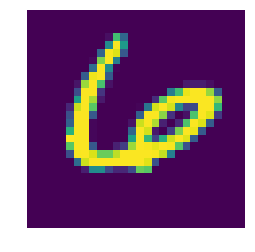

Label =  [[ 0.  0.  0.  0.  0.  0.  1.  0.  0.  0.]]
Class probabilities =  [[  3.59805243e-04   6.58656973e-06   5.26350783e-03   8.48718992e-05
    9.36258510e-02   1.88619215e-05   8.44072938e-01   2.85940617e-02
    5.35306940e-03   2.26204991e-02]]


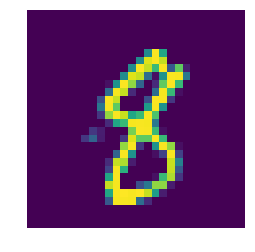

Label =  [[ 0.  0.  0.  0.  0.  0.  0.  0.  1.  0.]]
Class probabilities =  [[  1.30033266e-04   3.87917506e-03   1.01224063e-02   2.52482090e-02
    1.44047150e-02   4.26409282e-02   1.45911865e-04   1.89911807e-03
    8.69454384e-01   3.20750922e-02]]


In [15]:
for i in range(5):
    batch = mnist.test.next_batch(1)
    image = np.asarray(batch[0]).reshape((28, 28))
    label = batch[1]
    
    plt.imshow(image)
    plt.axis("off")
    plt.show()
    print "Label = ", label
    print "Class probabilities = ", y_probs_regressor.eval(feed_dict={
        x: batch[0], y_: batch[1]})

## Softmax Multi-Layer Perceptron on the MNIST Digits Data

Here we define both weight and bias variables and how they are to be initialized. Note that the weights are are distributed according to a standard normal distribution (mean = 0, std = 0.1). This random initialization helps avoid hidden units get stuck together, as units that start with the same value will be updated identically in the non-convolutional layers. In contrast, the bias variables are set to a small positive number--this is help prevent hidden units from starting out and getting stuck in the zero part of the ReLU. 

In [16]:
def weight_variable(shape):
  initial = tf.truncated_normal(shape, stddev=0.1)
  return tf.Variable(initial)

def bias_variable(shape):
  initial = tf.constant(0.1, shape=shape)
  return tf.Variable(initial)

Next we create placeholders for the training data.

In [17]:
x = tf.placeholder(tf.float32, shape=[None, 784])
y_ = tf.placeholder(tf.float32, shape=[None, 10])

We create the first and only fully connected hidden layer.

In [18]:
W_h = weight_variable([784, 512])
b_h = bias_variable([512])
h = tf.nn.relu(tf.matmul(x, W_h) + b_h)

We create the output layer.

In [19]:
W_out = weight_variable([512, 10])
b_out = bias_variable([10])
y_MLP = tf.matmul(h, W_out) + b_out

We again use cross entropy loss on a softmax distribution on the outputs.

In [20]:
cross_entropy = tf.reduce_mean(
    tf.nn.softmax_cross_entropy_with_logits(labels=y_, logits=y_MLP))

For training we choose an Adam learning rate and update rule. We then run this for 20,000 iterations and evaluate our accuracy after training. Note this softmax MLP network does quite a bit bettter than our softmax regressor. The non-linear layer really helps makes sense of the data! But we can do better still...

In [21]:
train_step = tf.train.AdamOptimizer(1e-4).minimize(cross_entropy)
correct_prediction = tf.equal(tf.argmax(y_MLP,1), tf.argmax(y_,1))
accuracy = tf.reduce_mean(tf.cast(correct_prediction, tf.float32))
sess.run(tf.global_variables_initializer())
for i in range(20000):
  batch = mnist.train.next_batch(50)
  if i%1000 == 0:
    train_accuracy = accuracy.eval(feed_dict={
        x:batch[0], y_: batch[1]})
    print("step %d, training accuracy %g"%(i, train_accuracy))
  train_step.run(feed_dict={x: batch[0], y_: batch[1]})

print("test accuracy %g"%accuracy.eval(feed_dict={
    x: mnist.test.images, y_: mnist.test.labels}))

step 0, training accuracy 0.16
step 1000, training accuracy 0.88
step 2000, training accuracy 0.94
step 3000, training accuracy 0.86
step 4000, training accuracy 1
step 5000, training accuracy 0.96
step 6000, training accuracy 1
step 7000, training accuracy 0.98
step 8000, training accuracy 0.96
step 9000, training accuracy 0.98
step 10000, training accuracy 1
step 11000, training accuracy 0.98
step 12000, training accuracy 0.98
step 13000, training accuracy 0.98
step 14000, training accuracy 0.98
step 15000, training accuracy 1
step 16000, training accuracy 0.98
step 17000, training accuracy 1
step 18000, training accuracy 0.98
step 19000, training accuracy 1
test accuracy 0.978


## A Simple Convolutional Neural Network: LeNet

Here we make our first CNN. It's quite simple network, but it's surprisingly good at this handwritten digit recognition task. This a variant on Yann LeCun's CNN network that really helped to move deep learning forward.

We define both weight and bias variables and how they are to be initialized. Note that the weights are are distributed according to a standard normal distribution (mean = 0, std = 0.1). This random initialization helps avoid hidden units get stuck together, as units that start with the same value will be updated identically in the non-convolutional layers. In contrast, the bias variables are set to a small positive number--this is help prevent hidden units from starting out and getting stuck in the zero part of the ReLu. 

In [22]:
def weight_variable(shape):
  initial = tf.truncated_normal(shape, stddev=0.1)
  return tf.Variable(initial)

def bias_variable(shape):
  initial = tf.constant(0.1, shape=shape)
  return tf.Variable(initial)

Next we define how the convolution is to be computed and the extent and type of pooling. The convolution will use a 5x5 kernel and will pad the image with zeros around the edges and use a stride of 1 pixel so that the resulting image (after convolution) has the same size as the original input image. The network will learn the weights for a stack of 32 separate kernels along with 32 bias variables. Finally, after the ReLu is performed the result will be under go 2x2 max pooling, thus halfing both dimensions of the image. The choices for the stride, padding, and pooling are not parameters that the network needs to estimate. Rather these are termed "hyperparamters" that are usually set by the network designer.

In [23]:
def conv2d(x, W):
  return tf.nn.conv2d(x, W, strides=[1, 1, 1, 1], padding='SAME')

def max_pool_2x2(x):
  return tf.nn.max_pool(x, ksize=[1, 2, 2, 1],
                        strides=[1, 2, 2, 1], padding='SAME')

This creates the weight and bias variables for the first convolutional layer as described above. Note the output has depth 32, so there will be 32 feature images after this layer.

In [24]:
W_conv1 = weight_variable([5, 5, 1, 32])
b_conv1 = bias_variable([32])

Unlike for our softmax regressor above, here we need keep the images as images and not collapse these into vectors; this allows us to perform the 2D convolution.

In [25]:
x_image = tf.reshape(x, [-1,28,28,1])

Finally, we define are first layer of our CNN!

In [26]:
h_conv1 = tf.nn.relu(conv2d(x_image, W_conv1) + b_conv1)
h_pool1 = max_pool_2x2(h_conv1)

And wasting no time, we define are second layer. The second layer will have to process 32 feature images coming out of the first layer. Note that the images input to this layer have $\frac{1}{4}$ the number of pixels as the original input images due to the 2x2 pooling in the previous layer. Note that convolution layer NOT fully connected as our previous hidden layers have been. A unit in the output layer has a limited "receptive field." Its connections to the input layer are spatially limited by the kernel (or filter) size. Also, because of weight sharing in convolutional layers, the number of parameters for a convolutional is the size of the kernel x the depth of the input layer x depth of the output layer + depth of the output layer. So for the second layer of our ConvNet, we have 5 x 5 x 32 x 64 + 64 = 51,264 parameters. 

In [27]:
W_conv2 = weight_variable([5, 5, 32, 64])
b_conv2 = bias_variable([64])

h_conv2 = tf.nn.relu(conv2d(h_pool1, W_conv2) + b_conv2)
h_pool2 = max_pool_2x2(h_conv2)

After the pooling stage of our second convolutional layer, we have 64 7x7 "feature" images. In one penultimate fully connected hidden layer, we are going to map these feature imges to a 1024 dimensional feature space. Note we need to flatten these feature images to do this.

In [28]:
W_fc1 = weight_variable([7 * 7 * 64, 1024])
b_fc1 = bias_variable([1024])

h_pool2_flat = tf.reshape(h_pool2, [-1, 7*7*64])
h_fc1 = tf.nn.relu(tf.matmul(h_pool2_flat, W_fc1) + b_fc1)

Dropout is added here, although it is not really needed for such small network.

In [29]:
keep_prob = tf.placeholder(tf.float32)
h_fc1_drop = tf.nn.dropout(h_fc1, keep_prob)

We have a final linear output layer mapping features to scores topped off with a softmax cross entropy loss function, as explained earlier.

In [30]:
W_fc2 = weight_variable([1024, 10])
b_fc2 = bias_variable([10])

y_conv = tf.matmul(h_fc1_drop, W_fc2) + b_fc2

In [31]:
cross_entropy = tf.reduce_mean(
    tf.nn.softmax_cross_entropy_with_logits(labels=y_, logits=y_conv))

For training we choose an Adam learning rate and update rule. We then run this for 20,000 iterations and evaluate our accuracy after training.

In [32]:
train_step = tf.train.AdamOptimizer(1e-4).minimize(cross_entropy)
correct_prediction = tf.equal(tf.argmax(y_conv,1), tf.argmax(y_,1))
accuracy = tf.reduce_mean(tf.cast(correct_prediction, tf.float32))
sess.run(tf.global_variables_initializer())
for i in range(20000):
  batch = mnist.train.next_batch(50)
  if i%1000 == 0:
    train_accuracy = accuracy.eval(feed_dict={
        x:batch[0], y_: batch[1], keep_prob: 1.0})
    print("step %d, training accuracy %g"%(i, train_accuracy))
  train_step.run(feed_dict={x: batch[0], y_: batch[1], keep_prob: 0.5})

print("test accuracy %g"%accuracy.eval(feed_dict={
    x: mnist.test.images, y_: mnist.test.labels, keep_prob: 1.0}))

step 0, training accuracy 0.06
step 1000, training accuracy 0.92
step 2000, training accuracy 0.94
step 3000, training accuracy 0.94
step 4000, training accuracy 0.98
step 5000, training accuracy 1
step 6000, training accuracy 1
step 7000, training accuracy 0.98
step 8000, training accuracy 0.98
step 9000, training accuracy 0.96
step 10000, training accuracy 1
step 11000, training accuracy 1
step 12000, training accuracy 0.98
step 13000, training accuracy 1
step 14000, training accuracy 0.98
step 15000, training accuracy 0.98
step 16000, training accuracy 0.98
step 17000, training accuracy 1
step 18000, training accuracy 1
step 19000, training accuracy 1
test accuracy 0.9918


We add an output to compuational graph that computes the label probabilities.

In [33]:
y_probs = tf.nn.softmax(logits=y_conv, name=None)

In [34]:
print("test accuracy %g"%accuracy.eval(feed_dict={
    x: mnist.test.images, y_: mnist.test.labels, keep_prob: 1.0}))

test accuracy 0.9918


Next we step through some test examples and see how well the network is doing.

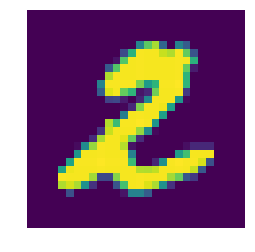

Label =  [[ 0.  0.  1.  0.  0.  0.  0.  0.  0.  0.]]
Class probabilities =  [[  9.82561144e-09   4.02944625e-06   9.99995232e-01   5.52794063e-07
    1.14567238e-10   1.30734061e-11   7.62288344e-13   4.52927162e-09
    2.44272286e-07   1.41098175e-10]]


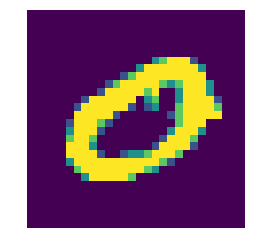

Label =  [[ 1.  0.  0.  0.  0.  0.  0.  0.  0.  0.]]
Class probabilities =  [[  1.00000000e+00   9.55037915e-14   1.00204497e-11   2.00734178e-12
    3.00243597e-12   3.60783655e-14   1.24180177e-09   1.54670330e-13
    7.29696360e-13   2.63964184e-09]]


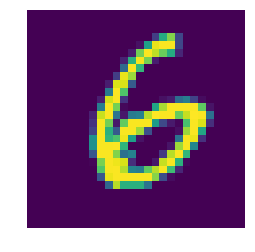

Label =  [[ 0.  0.  0.  0.  0.  0.  1.  0.  0.  0.]]
Class probabilities =  [[  1.78678743e-08   2.13080692e-14   4.30018190e-13   4.07494879e-14
    1.43967737e-13   6.06006356e-10   1.00000000e+00   5.61956352e-14
    3.06867398e-09   5.18705174e-12]]


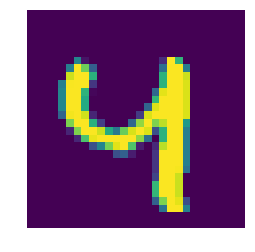

Label =  [[ 0.  0.  0.  0.  1.  0.  0.  0.  0.  0.]]
Class probabilities =  [[  3.71149969e-13   1.06815790e-09   2.73056697e-13   6.85211055e-10
    9.96720254e-01   3.12911502e-11   6.12383234e-12   7.73536044e-08
    2.03020356e-09   3.27958562e-03]]


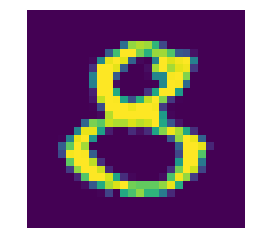

Label =  [[ 0.  0.  0.  0.  0.  0.  0.  0.  1.  0.]]
Class probabilities =  [[  1.98779659e-08   3.16471266e-10   1.29028317e-08   2.70781084e-03
    1.94473682e-08   9.44827661e-06   2.06461635e-07   1.81933218e-10
    9.97282028e-01   5.10022801e-07]]


In [35]:
for i in range(5):
    batch = mnist.test.next_batch(1)
    image = np.asarray(batch[0]).reshape((28, 28))
    label = batch[1]
    
    plt.imshow(image)
    plt.axis("off")
    plt.show()
    print "Label = ", label
    print "Class probabilities = ", y_probs.eval(feed_dict={
        x: batch[0], y_: batch[1], keep_prob: 1.0})

# Softmax regression model
## a,b,e,f) Re-implementation using Pytorch 

In [1]:
import torch
# import torchvision
from torchvision import datasets
from torchvision.transforms import ToTensor

In [2]:
#download MNIST Data
train_data = datasets.MNIST(root='/data', train=True, transform= ToTensor(), download=True)
test_data = datasets.MNIST( root='/data', train=False, transform= ToTensor(), download=True)

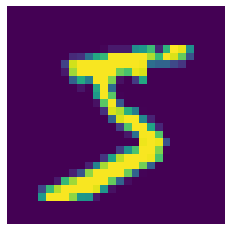

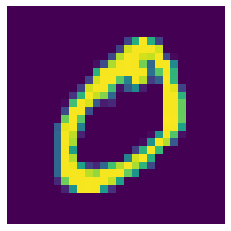

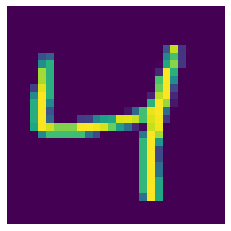

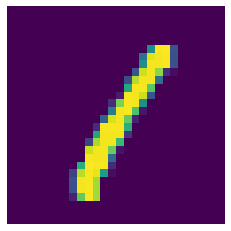

In [3]:
#Plot MNIST Data
import matplotlib.pyplot as plt
import numpy as np

for i in range(4):  
    plt.imshow(train_data.data[i])
    plt.axis("off")
    plt.show()

In [4]:
# Define batch size, no of iterations and epochs. Input dimension is 28x28 pixels and output dimension is 10. 
batch_size = 100
n_iters = 5000
epochs = n_iters / (len(train_data) / batch_size)
input_dim = 784 #28x28
output_dim = 10

In [5]:
#create data loaders for training, validation and testing
from torch.utils.data.sampler import SubsetRandomSampler

#indices for creating training and validation dataset
indices = list(range(len(train_data)))
np.random.shuffle(indices)
split = int(np.floor(0.2 * len(train_data)))
train_index, valid_index = indices[split:], indices[:split]

# define samplers for obtaining training and validation batches
train_sampler = SubsetRandomSampler(train_index)
valid_sampler = SubsetRandomSampler(valid_index)

train_loader = torch.utils.data.DataLoader(dataset=train_data, batch_size=batch_size, sampler=train_sampler)
valid_loader = torch.utils.data.DataLoader(dataset=train_data, batch_size=batch_size, sampler=valid_sampler)
test_loader = torch.utils.data.DataLoader(dataset=test_data, batch_size=batch_size, shuffle=False)

In [7]:
#Define class for Logistic regression
class LogisticRegression(torch.nn.Module):
    def __init__(self, input_dim, output_dim):
        super(LogisticRegression, self).__init__()
        self.linear = torch.nn.Linear(input_dim, output_dim)

    def forward(self, x):
        outputs = self.linear(x)
        return outputs
    
model = LogisticRegression(input_dim, output_dim)
print(model)

LogisticRegression(
  (linear): Linear(in_features=784, out_features=10, bias=True)
)


In [8]:
criterion = torch.nn.CrossEntropyLoss() # computes softmax and then the cross entropy
# Use Adam Optimization Algorithm
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

In [11]:
iter = 0
#initialize tracker for minimum validation loss
valid_loss_min = np.Inf  # set initial "min" to infinity

for epoch in range(int(epochs)):
    # monitor losses
    train_loss = 0
    valid_loss = 0
    
    # train the model
    model.train() #prep the model for training
    
    for images, labels in train_loader:
        # Load images as Variable
        images = images.view(-1, 28*28).requires_grad_()
        labels = labels
        # clear the gradients of all optimized variables
        optimizer.zero_grad()
        # forward pass: compute predicted outputs by passing inputs to the model
        outputs = model(images)
        #calculate the loss
        loss = criterion(outputs, labels)
        # backward pass: compute gradient of the loss with respect to model parameters
        loss.backward()
        # perform a single optimization step (parameter update)
        optimizer.step()
        # update running training loss
        train_loss += loss.item() * images.size(0)

        
        
    # validate the model
    model.eval()  # prep model for evaluation
    for images,labels in valid_loader:
        # Load images as Variable
        images = images.view(-1, 28*28).requires_grad_()
        labels = labels
        # forward pass: compute predicted outputs by passing inputs to the model
        outputs = model(images)
        # calculate the loss
        loss = criterion(outputs,labels)
        # update running validation loss 
        valid_loss = loss.item() * images.size(0)
    
    # print training/validation statistics 
    # calculate average loss over an epoch
    train_loss = train_loss / len(train_loader.sampler)
    valid_loss = valid_loss / len(valid_loader.sampler)
    
    print('Epoch: {} \tTraining Loss: {:.6f} \tValidation Loss: {:.6f}'.format(
        epoch+1, 
        train_loss,
        valid_loss
        ))
    
    # save model if validation loss has decreased
    if valid_loss <= valid_loss_min:
        print('Validation loss decreased ({:.6f} --> {:.6f}).  Saving model ...'.format(
        valid_loss_min,
        valid_loss))
        torch.save(model.state_dict(), 'model.pt')
        valid_loss_min = valid_loss

Epoch: 1 	Training Loss: 0.363321 	Validation Loss: 0.003360
Validation loss decreased (inf --> 0.003360).  Saving model ...
Epoch: 2 	Training Loss: 0.320512 	Validation Loss: 0.002358
Validation loss decreased (0.003360 --> 0.002358).  Saving model ...
Epoch: 3 	Training Loss: 0.300320 	Validation Loss: 0.003274
Epoch: 4 	Training Loss: 0.288006 	Validation Loss: 0.001850
Validation loss decreased (0.002358 --> 0.001850).  Saving model ...
Epoch: 5 	Training Loss: 0.280044 	Validation Loss: 0.002896
Epoch: 6 	Training Loss: 0.273269 	Validation Loss: 0.002225
Epoch: 7 	Training Loss: 0.269096 	Validation Loss: 0.002872
Epoch: 8 	Training Loss: 0.264187 	Validation Loss: 0.001572
Validation loss decreased (0.001850 --> 0.001572).  Saving model ...


# c) an evaluation of the accuracy on the MNIST test set

In [12]:
# initialize lists to monitor test loss and accuracy
test_loss = 0.0
class_correct = list(0. for i in range(10))
class_total = list(0. for i in range(10))

model.eval() # prep model for evaluation

for images, target in test_loader:
    # Load images as Variable
    images = images.view(-1, 28*28).requires_grad_()
    target = target
    # forward pass: compute predicted outputs by passing inputs to the model
    output = model(images)
    # calculate the loss
    loss = criterion(output, target)
    # update test loss 
    test_loss += loss.item()*images.size(0)
    
    # convert output probabilities to predicted class
    _, pred = torch.max(output, 1)
    # compare predictions to true label
    correct = np.squeeze(pred.eq(target.data.view_as(pred)))
    # calculate test accuracy for each object class
    for i in range(len(target)):
        label = target.data[i]
        class_correct[label] += correct[i].item()
        class_total[label] += 1
        
# calculate and print avg test loss
test_loss = test_loss/len(test_loader.sampler)
print('Test Loss: {:.6f}'.format(test_loss))
print('Test Accuracy (Overall): %2d%% (%2d/%2d)' % (
    100. * np.sum(class_correct) / np.sum(class_total),
    np.sum(class_correct), np.sum(class_total)))

Test Loss: 0.270760
Test Accuracy (Overall): 92% (9244/10000)


# d) Plots of 10 randomly selected digits from the test set along with the correct label and the assigned label

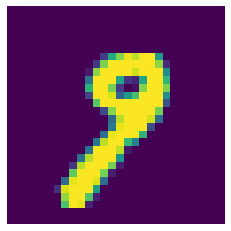

Correct label: 9
Assigned label: 9


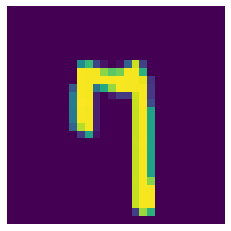

Correct label: 7
Assigned label: 7


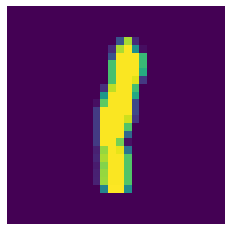

Correct label: 1
Assigned label: 1


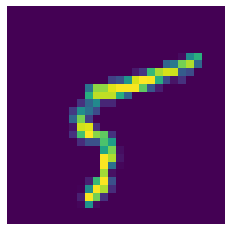

Correct label: 5
Assigned label: 5


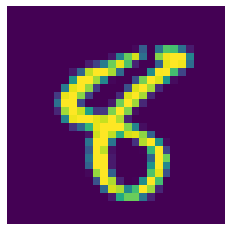

Correct label: 8
Assigned label: 8


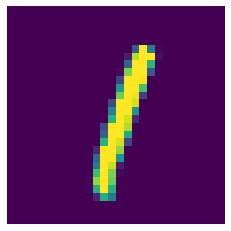

Correct label: 1
Assigned label: 1


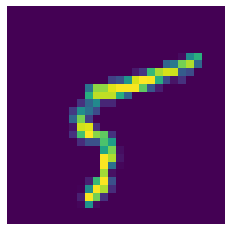

Correct label: 5
Assigned label: 5


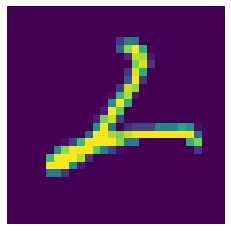

Correct label: 2
Assigned label: 2


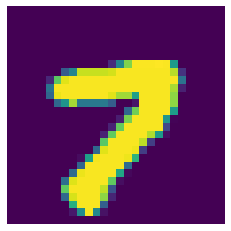

Correct label: 7
Assigned label: 7


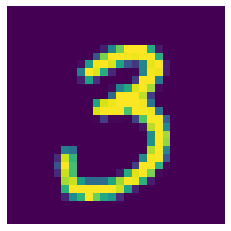

Correct label: 3
Assigned label: 3


In [13]:
iter_test = 0
for images, labels in test_loader:
    iter_test += 1
    images = images.view(-1, 28*28).requires_grad_()
    outputs = model(images)
    _, predicted = torch.max(outputs.data, 1)
    if iter_test == 1:
        
        for i in range(10):
            idx = np.random.randint(len(test_loader))
            plt.imshow(test_data[idx][0].numpy().reshape(28, 28))
            plt.axis("off")
            plt.show()
            print(f'Correct label: {labels[idx]}')
            print(f'Assigned label: {predicted[idx]}')

# f) after training, load the saved weights using the best model so far. re-run you accuracy evaluation using these saved weights

In [14]:
#load model with lowest validation loss
model.load_state_dict(torch.load('model.pt'))

<All keys matched successfully>

In [15]:
# initialize lists to monitor test loss and accuracy
test_loss = 0.0
class_correct = list(0. for i in range(10))
class_total = list(0. for i in range(10))

model.eval() # prep model for evaluation

for images, target in test_loader:
    # Load images as Variable
    images = images.view(-1, 28*28).requires_grad_()
    target = target
    # forward pass: compute predicted outputs by passing inputs to the model
    output = model(images)
    # calculate the loss
    loss = criterion(output, target)
    # update test loss 
    test_loss += loss.item()*images.size(0)
    
    # convert output probabilities to predicted class
    _, pred = torch.max(output, 1)
    # compare predictions to true label
    correct = np.squeeze(pred.eq(target.data.view_as(pred)))
    # calculate test accuracy for each object class
    for i in range(len(target)):
        label = target.data[i]
        class_correct[label] += correct[i].item()
        class_total[label] += 1
        
# calculate and print avg test loss
test_loss = test_loss/len(test_loader.sampler)
print('Test Loss: {:.6f}'.format(test_loss))
print('Test Accuracy (Overall): %2d%% (%2d/%2d)' % (
    100. * np.sum(class_correct) / np.sum(class_total),
    np.sum(class_correct), np.sum(class_total)))

Test Loss: 0.270760
Test Accuracy (Overall): 92% (9244/10000)


# Softmax Multi-Layer Perceptron on the MNIST Digits Data

## a,b,e,f) Re-implementation using Pytorch

In [19]:
import torch.nn as nn
import torch.nn.functional as F
# define NN architecture
class Net(nn.Module):
    def __init__(self):
        super(Net,self).__init__()
        # number of hidden nodes in each layer (512)
        hidden_1 = 512
        hidden_2 = 512
        # linear layer (784 -> hidden_1)
        self.fc1 = nn.Linear(28*28, 512)
        # linear layer (n_hidden -> hidden_2)
        self.fc2 = nn.Linear(512,512)
        # linear layer (n_hidden -> 10)
        self.fc3 = nn.Linear(512,10)
        # dropout layer (p=0.2)
        # dropout prevents overfitting of data
        self.droput = nn.Dropout(0.2)
        
    def forward(self,x):
        # flatten image input
        x = x.view(-1,28*28)
        # add hidden layer, with relu activation function
        x = F.relu(self.fc1(x))
        # add dropout layer
        x = self.droput(x)
         # add hidden layer, with relu activation function
        x = F.relu(self.fc2(x))
        # add dropout layer
        x = self.droput(x)
        # add output layer
        x = self.fc3(x)
        # 
        return F.log_softmax(x, dim=1)

# initialize the NN
model = Net()
print(model)

Net(
  (fc1): Linear(in_features=784, out_features=512, bias=True)
  (fc2): Linear(in_features=512, out_features=512, bias=True)
  (fc3): Linear(in_features=512, out_features=10, bias=True)
  (droput): Dropout(p=0.2, inplace=False)
)


In [20]:
# specify loss function (categorical cross-entropy)
criterion = nn.CrossEntropyLoss()
# specify optimizer (stochastic gradient descent) and learning rate = 0.01
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

In [21]:
# initialize tracker for minimum validation loss
valid_loss_min = np.Inf  # set initial "min" to infinity
for epoch in range(int(epochs)):
    # monitor losses
    train_loss = 0
    valid_loss = 0
    
     
    # train the model
    model.train() # prep model for training
    for images,labels in train_loader:
        # clear the gradients of all optimized variables
        optimizer.zero_grad()
        # forward pass: compute predicted outputs by passing inputs to the model
        output = model(images)
        # calculate the loss
        loss = criterion(output,labels)
        # backward pass: compute gradient of the loss with respect to model parameters
        loss.backward()
        # perform a single optimization step (parameter update)
        optimizer.step()
        # update running training loss
        train_loss += loss.item() * images.size(0)
        
 
    # validate the model
    model.eval()  # prep model for evaluation
    for images,labels in valid_loader:
        # forward pass: compute predicted outputs by passing inputs to the model
        output = model(images)
        # calculate the loss
        loss = criterion(output,labels)
        # update running validation loss 
        valid_loss = loss.item() * images.size(0)
    
    # print training/validation statistics 
    # calculate average loss over an epoch
    train_loss = train_loss / len(train_loader.sampler)
    valid_loss = valid_loss / len(valid_loader.sampler)
    
    print('Epoch: {} \tTraining Loss: {:.6f} \tValidation Loss: {:.6f}'.format(
        epoch+1, 
        train_loss,
        valid_loss
        ))
    
    # save model if validation loss has decreased
    if valid_loss <= valid_loss_min:
        print('Validation loss decreased ({:.6f} --> {:.6f}).  Saving model ...'.format(
        valid_loss_min,
        valid_loss))
        torch.save(model.state_dict(), 'model.pt')
        valid_loss_min = valid_loss

Epoch: 1 	Training Loss: 0.298088 	Validation Loss: 0.001229
Validation loss decreased (inf --> 0.001229).  Saving model ...
Epoch: 2 	Training Loss: 0.112746 	Validation Loss: 0.000459
Validation loss decreased (0.001229 --> 0.000459).  Saving model ...
Epoch: 3 	Training Loss: 0.080164 	Validation Loss: 0.000542
Epoch: 4 	Training Loss: 0.062523 	Validation Loss: 0.000717
Epoch: 5 	Training Loss: 0.051526 	Validation Loss: 0.000552
Epoch: 6 	Training Loss: 0.044277 	Validation Loss: 0.000207
Validation loss decreased (0.000459 --> 0.000207).  Saving model ...
Epoch: 7 	Training Loss: 0.035305 	Validation Loss: 0.000226
Epoch: 8 	Training Loss: 0.030866 	Validation Loss: 0.001216


# c) an evaluation of the accuracy on the MNIST test set

In [22]:
# initialize lists to monitor test loss and accuracy
test_loss = 0.0
class_correct = list(0. for i in range(10))
class_total = list(0. for i in range(10))

model.eval() # prep model for evaluation

for images, target in test_loader:
    # Load images as Variable
    images = images.view(-1, 28*28).requires_grad_()
    target = target
    # forward pass: compute predicted outputs by passing inputs to the model
    output = model(images)
    # calculate the loss
    loss = criterion(output, target)
    # update test loss 
    test_loss += loss.item()*images.size(0)
    
    # convert output probabilities to predicted class
    _, pred = torch.max(output, 1)
    # compare predictions to true label
    correct = np.squeeze(pred.eq(target.data.view_as(pred)))
    # calculate test accuracy for each object class
    for i in range(len(target)):
        label = target.data[i]
        class_correct[label] += correct[i].item()
        class_total[label] += 1
        
# calculate and print avg test loss
test_loss = test_loss/len(test_loader.sampler)
print('Test Loss: {:.6f}'.format(test_loss))
print('Test Accuracy (Overall): %2d%% (%2d/%2d)' % (
    100. * np.sum(class_correct) / np.sum(class_total),
    np.sum(class_correct), np.sum(class_total)))

Test Loss: 0.077415
Test Accuracy (Overall): 97% (9779/10000)


# d) Plots of 10 randomly selected digits from the test set along with the correct label and the assigned label

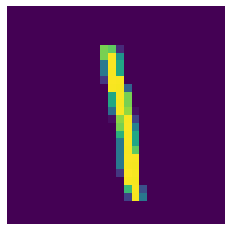

Correct label: 1
Assigned label: 1


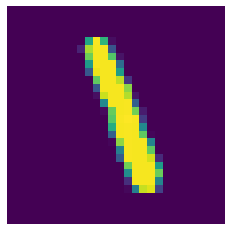

Correct label: 1
Assigned label: 1


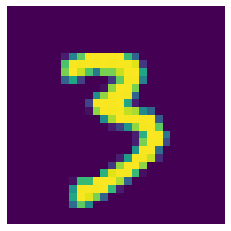

Correct label: 3
Assigned label: 3


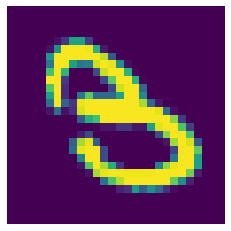

Correct label: 3
Assigned label: 3


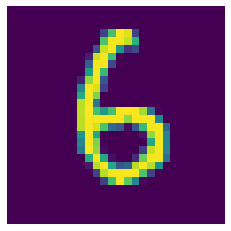

Correct label: 6
Assigned label: 6


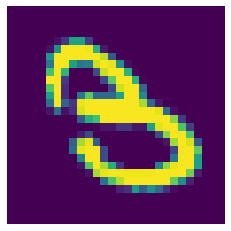

Correct label: 3
Assigned label: 3


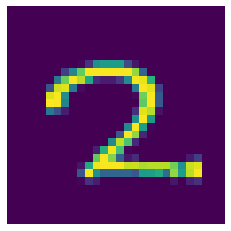

Correct label: 2
Assigned label: 2


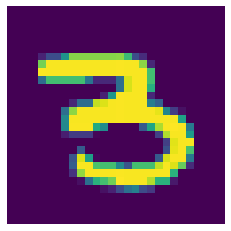

Correct label: 3
Assigned label: 3


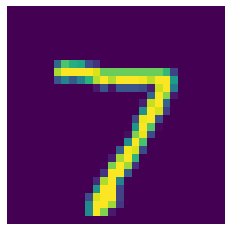

Correct label: 7
Assigned label: 7


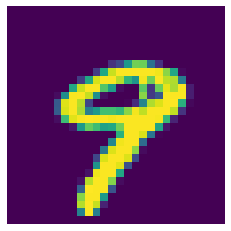

Correct label: 9
Assigned label: 9


In [23]:
iter_test = 0
for images, labels in test_loader:
    iter_test += 1
    images = images.view(-1, 28*28).requires_grad_()
    outputs = model(images)
    _, predicted = torch.max(outputs.data, 1)
    if iter_test == 1:
        
        for i in range(10):
            idx = np.random.randint(len(test_loader))
            plt.imshow(test_data[idx][0].numpy().reshape(28, 28))
            plt.axis("off")
            plt.show()
            print(f'Correct label: {labels[idx]}')
            print(f'Assigned label: {predicted[idx]}')

# f) after training, load the saved weights using the best model so far. re-run you accuracy evaluation using these saved weights

In [24]:
model.load_state_dict(torch.load('model.pt'))

<All keys matched successfully>

In [25]:
# initialize lists to monitor test loss and accuracy
test_loss = 0.0
class_correct = list(0. for i in range(10))
class_total = list(0. for i in range(10))

model.eval() # prep model for evaluation

for images, target in test_loader:
    # Load images as Variable
    images = images.view(-1, 28*28).requires_grad_()
    target = target
    # forward pass: compute predicted outputs by passing inputs to the model
    output = model(images)
    # calculate the loss
    loss = criterion(output, target)
    # update test loss 
    test_loss += loss.item()*images.size(0)
    
    # convert output probabilities to predicted class
    _, pred = torch.max(output, 1)
    # compare predictions to true label
    correct = np.squeeze(pred.eq(target.data.view_as(pred)))
    # calculate test accuracy for each object class
    for i in range(len(target)):
        label = target.data[i]
        class_correct[label] += correct[i].item()
        class_total[label] += 1
        
# calculate and print avg test loss
test_loss = test_loss/len(test_loader.sampler)
print('Test Loss: {:.6f}'.format(test_loss))
print('Test Accuracy (Overall): %2d%% (%2d/%2d)' % (
    100. * np.sum(class_correct) / np.sum(class_total),
    np.sum(class_correct), np.sum(class_total)))

Test Loss: 0.071276
Test Accuracy (Overall): 97% (9791/10000)


# A Simple Convolutional Neural Network: LeNet

# a,b,e,f) Re-implementation using Pytorch

In [26]:
class LeNet(nn.Module):
    def __init__(self):
        super(LeNet,self).__init__()
        
        #Layer 1: 6 kernels of size 5x5 with padding 0 and stride 1
        self.conv1 = nn.Conv2d(in_channels=1,out_channels=6,kernel_size=(5,5))
        #Layer 3: 16 kernels of size 5x5 with padding 0 and stride 1
        self.conv2 = nn.Conv2d(in_channels = 6, out_channels = 16,kernel_size = (5,5))
        #Layer 5: Flatten data
        self.L1 = nn.Linear(256, 120)
        #Layer 6: 85 Linear Neurons and input of 120
        self.L2 = nn.Linear(120,84)
        #Layer 7: 10 Linear Neurons and input of 84
        self.L3 = nn.Linear(84,10)

        self.pool = nn.AvgPool2d(kernel_size = 2, stride = 2)
        self.act = nn.Tanh()
    
    def forward(self,x):
        x = self.conv1(x)
        #tanh as an activation function
        x = self.act(x)
        #pooling 
        x = self.pool(x)
        #convolution
        x = self.conv2(x)
        x = self.act(x)
        x = self.pool(x)
        #next we will pass from conv3, here we will not pass data from pooling as per Architecture 
        
        
        #Now the data should be flaten and it would be passed from FC layers. 
        x = x.view(x.size()[0], -1)
        x = self.L1(x)
        x = self.act(x)
        x = self.L2(x)
        x = self.act(x)
        x = self.L3(x)
        
        return x

model = LeNet()
print(model)

LeNet(
  (conv1): Conv2d(1, 6, kernel_size=(5, 5), stride=(1, 1))
  (conv2): Conv2d(6, 16, kernel_size=(5, 5), stride=(1, 1))
  (L1): Linear(in_features=256, out_features=120, bias=True)
  (L2): Linear(in_features=120, out_features=84, bias=True)
  (L3): Linear(in_features=84, out_features=10, bias=True)
  (pool): AvgPool2d(kernel_size=2, stride=2, padding=0)
  (act): Tanh()
)


In [27]:
# specify loss function (categorical cross-entropy)
criterion = nn.CrossEntropyLoss()
# specify optimizer (stochastic gradient descent) and learning rate = 0.01
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

In [28]:
# initialize tracker for minimum validation loss
epochs = 20
valid_loss_min = np.Inf  # set initial "min" to infinity
for epoch in range(int(epochs)):
    # monitor losses
    train_loss = 0
    valid_loss = 0
    
     
    # train the model
    model.train() # prep model for training
    for images,labels in train_loader:
        # clear the gradients of all optimized variables
        optimizer.zero_grad()
        # forward pass: compute predicted outputs by passing inputs to the model
        output = model(images)
        # calculate the loss
        loss = criterion(output,labels)
        # backward pass: compute gradient of the loss with respect to model parameters
        loss.backward()
        # perform a single optimization step (parameter update)
        optimizer.step()
        # update running training loss
        train_loss += loss.item() * images.size(0)
        
 
    # validate the model
    model.eval()  # prep model for evaluation
    for images,labels in valid_loader:
        # forward pass: compute predicted outputs by passing inputs to the model
        output = model(images)
        # calculate the loss
        loss = criterion(output,labels)
        # update running validation loss 
        valid_loss = loss.item() * images.size(0)
    
    # print training/validation statistics 
    # calculate average loss over an epoch
    train_loss = train_loss / len(train_loader.sampler)
    valid_loss = valid_loss / len(valid_loader.sampler)
    
    print('Epoch: {} \tTraining Loss: {:.6f} \tValidation Loss: {:.6f}'.format(
        epoch+1, 
        train_loss,
        valid_loss
        ))
    
    # save model if validation loss has decreased
    if valid_loss <= valid_loss_min:
        print('Validation loss decreased ({:.6f} --> {:.6f}).  Saving model ...'.format(
        valid_loss_min,
        valid_loss))
        torch.save(model.state_dict(), 'model.pt')
        valid_loss_min = valid_loss

Epoch: 1 	Training Loss: 0.410759 	Validation Loss: 0.001574
Validation loss decreased (inf --> 0.001574).  Saving model ...
Epoch: 2 	Training Loss: 0.130400 	Validation Loss: 0.001272
Validation loss decreased (0.001574 --> 0.001272).  Saving model ...
Epoch: 3 	Training Loss: 0.084336 	Validation Loss: 0.000928
Validation loss decreased (0.001272 --> 0.000928).  Saving model ...
Epoch: 4 	Training Loss: 0.063330 	Validation Loss: 0.000551
Validation loss decreased (0.000928 --> 0.000551).  Saving model ...
Epoch: 5 	Training Loss: 0.050215 	Validation Loss: 0.000974
Epoch: 6 	Training Loss: 0.041330 	Validation Loss: 0.000548
Validation loss decreased (0.000551 --> 0.000548).  Saving model ...
Epoch: 7 	Training Loss: 0.034964 	Validation Loss: 0.000211
Validation loss decreased (0.000548 --> 0.000211).  Saving model ...
Epoch: 8 	Training Loss: 0.028608 	Validation Loss: 0.000058
Validation loss decreased (0.000211 --> 0.000058).  Saving model ...
Epoch: 9 	Training Loss: 0.025643 

# c) an evaluation of the accuracy on the MNIST test set

In [29]:
# initialize lists to monitor test loss and accuracy
test_loss = 0.0
class_correct = list(0. for i in range(10))
class_total = list(0. for i in range(10))

model.eval() # prep model for evaluation

for images, target in test_loader:
    # Load images as Variable
    # forward pass: compute predicted outputs by passing inputs to the model
    output = model(images)
    # calculate the loss
    loss = criterion(output, target)
    # update test loss 
    test_loss += loss.item()*images.size(0)
    
    # convert output probabilities to predicted class
    _, pred = torch.max(output, 1)
    # compare predictions to true label
    correct = np.squeeze(pred.eq(target.data.view_as(pred)))
    # calculate test accuracy for each object class
    for i in range(len(target)):
        label = target.data[i]
        class_correct[label] += correct[i].item()
        class_total[label] += 1
        
# calculate and print avg test loss
test_loss = test_loss/len(test_loader.sampler)
print('Test Loss: {:.6f}'.format(test_loss))
print('Test Accuracy (Overall): %2d%% (%2d/%2d)' % (
    100. * np.sum(class_correct) / np.sum(class_total),
    np.sum(class_correct), np.sum(class_total)))

Test Loss: 0.054805
Test Accuracy (Overall): 98% (9849/10000)


# d) Plots of 10 randomly selected digits from the test set along with the correct label and the assigned label

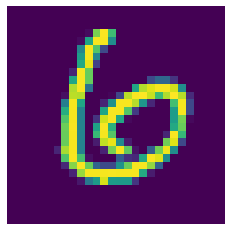

Correct label: 6
Assigned label: 6


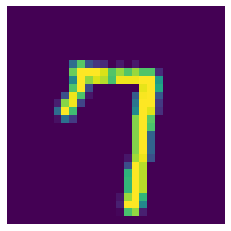

Correct label: 7
Assigned label: 7


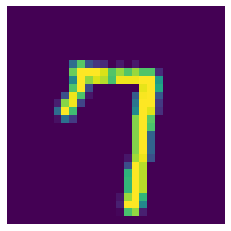

Correct label: 7
Assigned label: 7


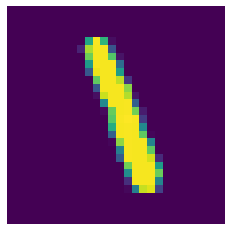

Correct label: 1
Assigned label: 1


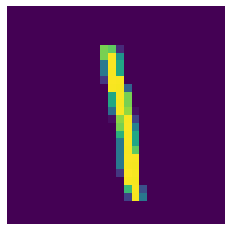

Correct label: 1
Assigned label: 1


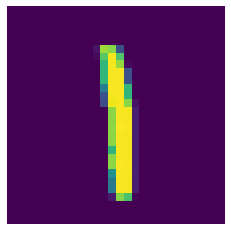

Correct label: 1
Assigned label: 1


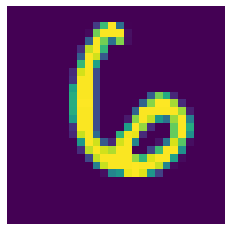

Correct label: 6
Assigned label: 6


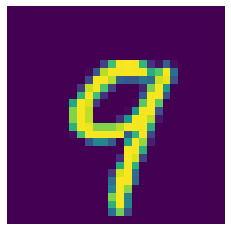

Correct label: 9
Assigned label: 9


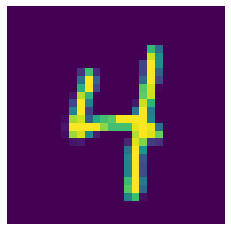

Correct label: 4
Assigned label: 4


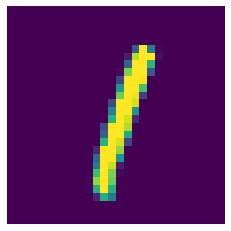

Correct label: 1
Assigned label: 1


In [30]:
iter_test = 0
for images, labels in test_loader:
    iter_test += 1
    outputs = model(images)
    _, predicted = torch.max(outputs.data, 1)
    if iter_test == 1:
        
        for i in range(10):
            idx = np.random.randint(len(test_loader))
            plt.imshow(test_data[idx][0].numpy().reshape(28, 28))
            plt.axis("off")
            plt.show()
            print(f'Correct label: {labels[idx]}')
            print(f'Assigned label: {predicted[idx]}')

# f) after training, load the saved weights using the best model so far. re-run you accuracy evaluation using these saved weights

In [31]:
model.load_state_dict(torch.load('model.pt'))

<All keys matched successfully>

In [32]:
# initialize lists to monitor test loss and accuracy
test_loss = 0.0
class_correct = list(0. for i in range(10))
class_total = list(0. for i in range(10))

model.eval() # prep model for evaluation

for images, target in test_loader:
    # Load images as Variable
    # forward pass: compute predicted outputs by passing inputs to the model
    output = model(images)
    # calculate the loss
    loss = criterion(output, target)
    # update test loss 
    test_loss += loss.item()*images.size(0)
    
    # convert output probabilities to predicted class
    _, pred = torch.max(output, 1)
    # compare predictions to true label
    correct = np.squeeze(pred.eq(target.data.view_as(pred)))
    # calculate test accuracy for each object class
    for i in range(len(target)):
        label = target.data[i]
        class_correct[label] += correct[i].item()
        class_total[label] += 1
        
# calculate and print avg test loss
test_loss = test_loss/len(test_loader.sampler)
print('Test Loss: {:.6f}'.format(test_loss))
print('Test Accuracy (Overall): %2d%% (%2d/%2d)' % (
    100. * np.sum(class_correct) / np.sum(class_total),
    np.sum(class_correct), np.sum(class_total)))

Test Loss: 0.048672
Test Accuracy (Overall): 98% (9843/10000)
